In [2]:
# Import necessary libraries for web scraping and automation
import csv
from bs4 import BeautifulSoup
from selenium import webdriver
from selenium.webdriver.edge.service import Service
from selenium.webdriver.edge.options import Options

In [4]:
# Function to generate the URL for the search term on Amazon
def get_url(search_term):
    template = 'https://www.amazon.com/s?k={}&ref=nb_sb_noss_1'
    search_term = search_term.replace(' ', '+') # This function replaces spaces in the search term with '+' and formats the URL.
    return template.format(search_term)

In [6]:
# Function to extract details like description, URL, price, and rating from a product record
def extract_record(item):
    """Extract and return data from a single record."""
    # Description and URL
    try:
        atag = item.h2.a
        description = atag.text.strip()
        url = 'https://www.amazon.com' + atag.get('href')
    except AttributeError:
        description = 'N/A'
        url = 'N/A'

    # Product price
    try:
        price_parent = item.find('span', 'a-price')
        price = price_parent.find('span', 'a-offscreen').text
    except AttributeError:
        price = 'N/A'

    # Rating and Review Count
    try:
        rating = item.find('span', class_='a-icon-alt').text.split(' ')[0]
    except AttributeError:
        rating = 'N/A'

    try:
        review_count = item.find('span', {'class': 'a-size-base s-underline-text'}).text.replace(',', '').strip()
    except AttributeError:
        review_count = 'N/A'

    return (description, price, rating, review_count, url)
# It uses BeautifulSoup to parse the HTML and handle missing attributes gracefully.

In [8]:
def scrape_amazon(search_term, driver):
    """Scrape Amazon for a single product search term."""
    records = []
    url = get_url(search_term)

    # Loop over the first 20 pages
    for page in range(1, 21):
        driver.get(url + f'&page={page}')
        soup = BeautifulSoup(driver.page_source, 'html.parser')
        results = soup.find_all('div', {'data-component-type': 's-search-result'})

        if not results:
            print(f"No results found on page {page} for '{search_term}'.")
            break

        for item in results:
            record = extract_record(item)
            if record:
                records.append(record)
    return records

In [10]:
# Set up the Selenium WebDriver for Microsoft Edge. Ensure that both edge and drive version matches before installation. 
def main(search_terms, save_to_single_file=True):
    """Run the program for multiple search terms."""
    # Setup Edge options and service
    options = Options()
    options.use_chromium = True
    service = Service(executable_path='/usr/local/bin/msedgedriver')  # Path of driver
    driver = webdriver.Edge(service=service, options=options)

    all_records = []

    for term in search_terms:
        print(f"Scraping results for '{term}'...")
        records = scrape_amazon(term, driver)
        all_records.extend(records)

        if not save_to_single_file:
            # Save to a separate file for this term
            filename = f"{term.replace(' ', '_')}_results.csv"
            with open(filename, 'w', newline='', encoding='utf-8') as f:
                writer = csv.writer(f)
                writer.writerow(['Description', 'Price', 'Rating', 'ReviewCount', 'Url'])
                writer.writerows(records)
            print(f"Saved results for '{term}' to {filename}.")

    driver.quit()

    if save_to_single_file:
        # Save all records into a single file
        with open('all_results.csv', 'w', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            writer.writerow(['Description', 'Price', 'Rating', 'ReviewCount', 'Url'])
            writer.writerows(all_records)
        print("Saved all results to 'all_results.csv'.")

In [12]:
if __name__ == "__main__":
    # Prompt user for search terms
    print("Enter the search terms separated by commas (e.g., 'ultrawide monitor, gaming laptop, wireless keyboard'):")
    user_input = input("Search terms: ")
    
    # Split input into a list of terms
    search_terms = [term.strip() for term in user_input.split(',') if term.strip()]
    
    # Ensure at least one term is provided
    if not search_terms:
        print("No search terms provided. Exiting...")
    else:
        # Always save to a single file
        main(search_terms, save_to_single_file=True)

Enter the search terms separated by commas (e.g., 'ultrawide monitor, gaming laptop, wireless keyboard'):


Search terms:  ultrawide monitor, gaming laptop, wireless keyboard


Scraping results for 'ultrawide monitor'...
Scraping results for 'gaming laptop'...
Scraping results for 'wireless keyboard'...
Saved all results to 'all_results.csv'.


In [14]:
import pandas as pd

# Load the CSV file
data = pd.read_csv('all_results.csv')

# Remove rows with 'N/A' values
cleaned_data = data.dropna()

# Save the cleaned dataset
cleaned_data.to_csv('cleaned_results.csv', index=False)

print(f"Rows before cleaning: {len(data)}")
print(f"Rows after cleaning: {len(cleaned_data)}")

Rows before cleaning: 1255
Rows after cleaning: 1119


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
data = pd.read_csv('cleaned_results.csv')

# Generate summary table
summary_table = data.describe(include='all').transpose()

# Save the summary table to a CSV for reference
summary_table.to_csv('data_summary.csv', index=True)

# Print the summary table
print(summary_table)


              count unique                                                top  \
Description    1119   1019  NIMO 17.3 FHD Laptop, Intel 6 Core i3-1215U, 3...   
Price          1119    481                                             $39.99   
Rating       1119.0    NaN                                                NaN   
ReviewCount  1119.0    NaN                                                NaN   
Url            1119   1119  https://www.amazon.com/sspa/click?ie=UTF8&spc=...   

            freq         mean          std  min   25%    50%     75%      max  
Description    4          NaN          NaN  NaN   NaN    NaN     NaN      NaN  
Price         60          NaN          NaN  NaN   NaN    NaN     NaN      NaN  
Rating       NaN     4.335389     0.436217  1.0   4.2    4.4     4.6      5.0  
ReviewCount  NaN  2118.820375  5853.859912  1.0  22.0  228.0  1658.0  97757.0  
Url            1          NaN          NaN  NaN   NaN    NaN     NaN      NaN  


In [17]:

# Visualize data variety and size
plt.figure(figsize=(15, 10))


<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

Text(0.5, 1.0, 'Number of Unique Titles')

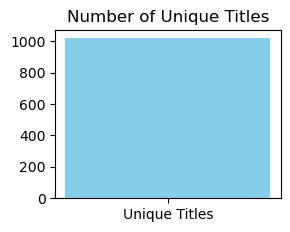

In [20]:
# Titles - Count of unique titles
plt.subplot(2, 2, 1)
unique_titles_count = data['Description'].nunique()
plt.bar(['Unique Titles'], [unique_titles_count], color='skyblue')
plt.title('Number of Unique Titles')


Text(0.5, 0, 'Price')

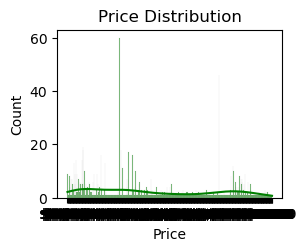

In [22]:

# Price - Distribution
plt.subplot(2, 2, 2)
sns.histplot(data['Price'], kde=True, bins=20, color='green')
plt.title('Price Distribution')
plt.xlabel('Price')



Text(0.5, 0, 'Rating')

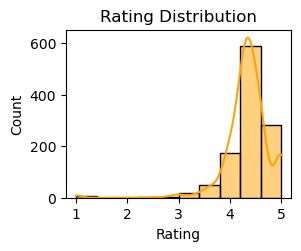

In [24]:
# Rating - Distribution
plt.subplot(2, 2, 3)
sns.histplot(data['Rating'], kde=True, bins=10, color='orange')
plt.title('Rating Distribution')
plt.xlabel('Rating')


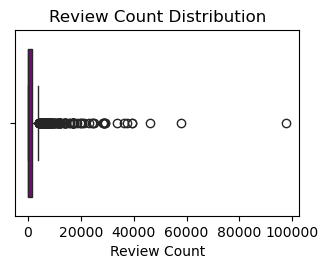

In [26]:
 #ReviewCount - Box Plot
plt.subplot(2, 2, 4)
sns.boxplot(x=data['ReviewCount'], color='purple')
plt.title('Review Count Distribution')
plt.xlabel('Review Count')

# Adjust layout
plt.tight_layout()

# Save figures
plt.savefig('data_summary_plots.png')

# Show plots
plt.show()

In [28]:
# Convert Price and ReviewCount to numeric (if not already)
data['Price'] = pd.to_numeric(data['Price'], errors='coerce')
data['ReviewCount'] = pd.to_numeric(data['ReviewCount'], errors='coerce')


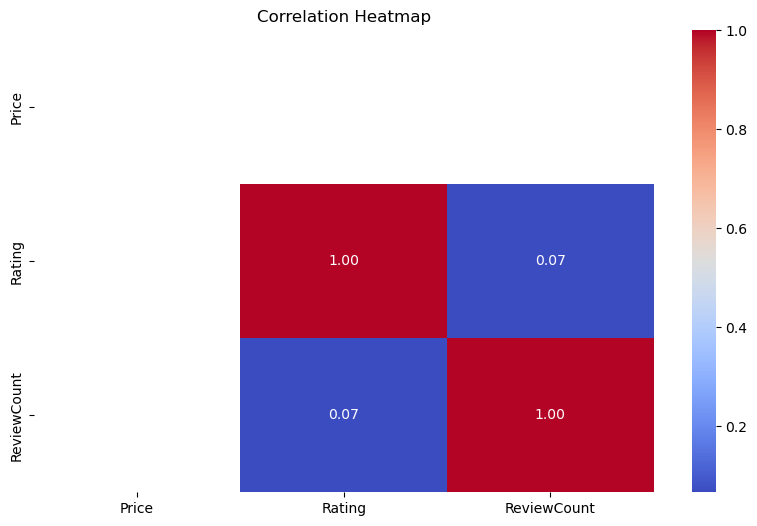

In [30]:

# Correlation Heatmap
plt.figure(figsize=(10, 6))
corr_matrix = data[['Price', 'Rating', 'ReviewCount']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.savefig('correlation_heatmap.png')
plt.show()


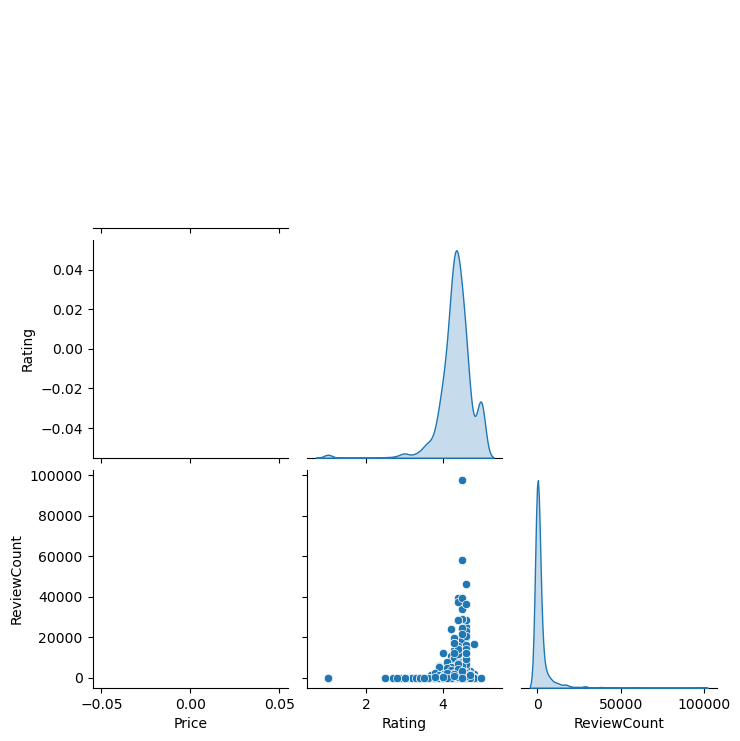

In [32]:

# Pair Plot - Relationships Between Variables
sns.pairplot(data[['Price', 'Rating', 'ReviewCount']], diag_kind='kde', corner=True)
plt.savefig('pairplot_relationships.png')
plt.show()